In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np



In [2]:
pip install tensorflow matplotlib numpy


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.8/351.2 MB 10.1 MB/s eta 0:00:35
   ---------------------------------------- 4.2/351.2 MB 10.2 MB/s eta 0:00:35
    --------------------------------------- 5.8/351.2 MB 9.7 MB/s eta 0:00:36
    --------------------------------------- 7.1/351.2 MB 8.5 MB/s eta 0:00:41
    --------------------------------------- 8.7/351.2 MB 8.3 MB/s eta 0:00:42
   - -------------------------------------- 10.7/351.2 MB 8.6 MB/s eta 0:00:40
   - -------------------------------------- 13.1/351.2 MB 8.9 MB/s eta 0:00:38
   - -------------------------------------- 15.2/351.2 MB 9.0 MB/s eta 0:00:38
   - -------------------------------------- 17.3/351.2 MB 9.2 MB/s eta 0:00:37
   -- ------------------------------------- 19.1/351.2 MB 9.1 MB/s eta 0:00:37
   -- ------------------------------------- 21.2/351.2 MB 9.1 MB/s eta 0:00:37
   -- ------------------------------------- 23.3/351.2 MB 9.2 


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: C:\Users\shita\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


In [4]:
# Load Fashion MNIST Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step 
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


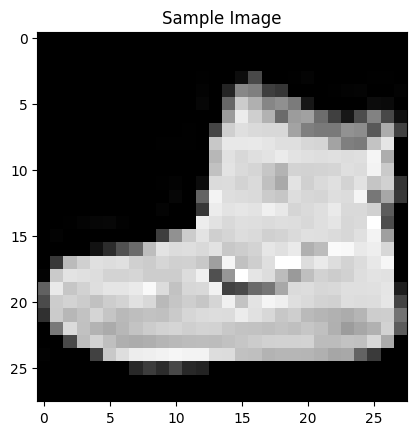

In [5]:
# Display Sample Image
plt.imshow(x_train[0], cmap='gray')
plt.title("Sample Image")
plt.show()

In [6]:
# Normalize the Data
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [7]:
# Reshape Data for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [8]:
# Build CNN Model
model = keras.Sequential([
    
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Dropout(0.25),

    keras.layers.Conv2D(128, (3,3), activation='relu'),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.25),

    keras.layers.Dense(10, activation='softmax')
])



C:\Users\shita\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.7946 - loss: 0.5574 - val_accuracy: 0.8537 - val_loss: 0.3987
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8667 - loss: 0.3640 - val_accuracy: 0.8873 - val_loss: 0.3099
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8833 - loss: 0.3173 - val_accuracy: 0.8913 - val_loss: 0.2962
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8922 - loss: 0.2925 - val_accuracy: 0.8893 - val_loss: 0.2907
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.8982 - loss: 0.2742 - val_accuracy: 0.8998 - val_loss: 0.2772
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9013 - loss: 0.2631 - val_accuracy: 0.9074 - val_loss: 0.2518
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.9076 - loss: 0.2487 - val_accuracy: 0.9030 - val_loss: 0.2619
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.9086 -

In [12]:
# Evaluate Model
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)



313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9071 - loss: 0.2582 
Test Accuracy: 0.9071000218391418


In [13]:
# Predict on Test Images
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


In [14]:
# Class Labels
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

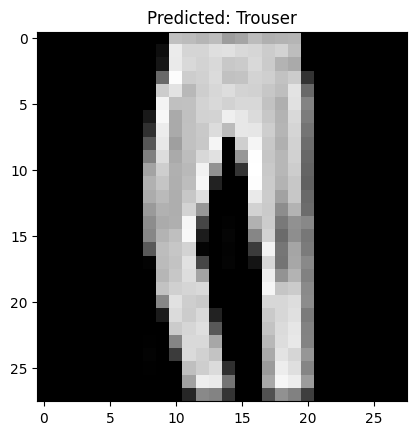

In [15]:
# Display Prediction
index = 5

plt.imshow(x_test[index].reshape(28,28), cmap='gray')
plt.title("Predicted: " + class_names[np.argmax(predictions[index])])
plt.show()